In [1]:
# ============================================================
# 1. Imports
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# 2. Load cleaned data
#    CHANGE THIS PATH to your cleaned CSV / parquet file
# ============================================================
# Example:
# df = pd.read_csv("cleaned_traffic_accidents.csv")

DATA_PATH = "../data/processed/cleaned_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nPreview:")
display(df.head())

Shape: (209275, 28)

Columns:
['crash_date', 'traffic_control_device', 'weather_condition', 'lighting_condition', 'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type', 'intersection_related_i', 'damage', 'prim_contributory_cause', 'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour', 'crash_day_of_week', 'crash_month', 'crash_datetime', 'crash_year', 'crash_day_name', 'any_injury']

Preview:


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month,crash_datetime,crash_year,crash_day_name,any_injury
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,13,7,7,2023-07-29 13:00:00,2023,Saturday,0
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,2.0,0,1,8,2023-08-13 00:11:00,2023,Sunday,0
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,10,5,12,2021-12-09 10:30:00,2021,Thursday,0
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,5.0,0.0,0.0,19,4,8,2023-08-09 19:55:00,2023,Wednesday,1
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,14,7,8,2023-08-19 14:55:00,2023,Saturday,0


In [3]:
# ============================================================
# 3. Helper functions
# ============================================================
def first_existing_column(df, candidates):
    """Return the first matching column name from a candidate list."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


def safe_to_datetime(series):
    return pd.to_datetime(series, errors="coerce")

In [4]:
# ============================================================
# 4. Build / confirm binary target: severe crash


df_model = df.copy()

df_model["severe"] = (
    (df_model["injuries_fatal"] > 0) |
    (df_model["injuries_incapacitating"] > 0)
).astype(int)

print(df_model["severe"].value_counts())
print(df_model["severe"].value_counts(normalize=True))


severe
0    202361
1      6914
Name: count, dtype: int64
severe
0    0.966962
1    0.033038
Name: proportion, dtype: float64


In [5]:
# ============================================================
# 5. Create interpretable pre-crash features
#
# This is important because the TA feedback suggested focusing on
# variables that are useful for prevention / planning, rather than
# only post-crash descriptors. 
# ============================================================

# ---- Datetime / hour features
datetime_col = first_existing_column(df_model, [
    "crash_datetime", "crash_date_time", "datetime", "date_time", "crash_timestamp"
])

date_col = first_existing_column(df_model, ["crash_date", "date"])
hour_col = first_existing_column(df_model, ["crash_hour", "hour"])
month_col = first_existing_column(df_model, ["crash_month", "month"])
dow_col = first_existing_column(df_model, ["crash_day_of_week", "day_of_week", "weekday"])

if hour_col is None and datetime_col is not None:
    df_model[datetime_col] = safe_to_datetime(df_model[datetime_col])
    df_model["crash_hour"] = df_model[datetime_col].dt.hour
    hour_col = "crash_hour"

if month_col is None and datetime_col is not None:
    df_model["crash_month"] = df_model[datetime_col].dt.month
    month_col = "crash_month"

if dow_col is None and datetime_col is not None:
    # Monday=0 ... Sunday=6
    df_model["crash_day_of_week"] = df_model[datetime_col].dt.dayofweek
    dow_col = "crash_day_of_week"

# If only crash_date exists, try parsing that too
if datetime_col is None and date_col is not None:
    df_model[date_col] = safe_to_datetime(df_model[date_col])
    if hour_col is None:
        df_model["crash_hour"] = 12  # placeholder if hour unavailable
        hour_col = "crash_hour"
    if month_col is None:
        df_model["crash_month"] = df_model[date_col].dt.month
        month_col = "crash_month"
    if dow_col is None:
        df_model["crash_day_of_week"] = df_model[date_col].dt.dayofweek
        dow_col = "crash_day_of_week"

# Basic derived time features
if hour_col is not None:
    df_model["rush_hour"] = df_model[hour_col].isin([7, 8, 9, 16, 17, 18]).astype(int)
    df_model["night_time"] = df_model[hour_col].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
else:
    df_model["rush_hour"] = 0
    df_model["night_time"] = 0

if dow_col is not None:
    # If Monday=0 ... Sunday=6
    if df_model[dow_col].dropna().isin(range(7)).all():
        df_model["weekend"] = df_model[dow_col].isin([5, 6]).astype(int)
    else:
        # If encoded 1..7
        df_model["weekend"] = df_model[dow_col].isin([6, 7]).astype(int)
else:
    df_model["weekend"] = 0


# ---- Weather grouping
weather_col = first_existing_column(df_model, [
    "weather_condition", "weather", "weather_type", "weather_desc"
])

if weather_col is not None:
    wc = df_model[weather_col].astype(str).str.upper()

    def map_weather_group(x):
        if "RAIN" in x or "DRIZZLE" in x:
            return "RAIN"
        elif "SNOW" in x or "SLEET" in x or "HAIL" in x:
            return "SNOW_ICE"
        elif "FOG" in x or "SMOKE" in x or "HAZE" in x:
            return "LOW_VIS"
        elif "CLEAR" in x:
            return "CLEAR"
        elif "CLOUD" in x or "OVERCAST" in x:
            return "CLOUDY"
        else:
            return "OTHER"

    df_model["weather_group"] = wc.apply(map_weather_group)
else:
    df_model["weather_group"] = "UNKNOWN"


# ---- Crosswalk / traffic-control feature
traffic_control_col = first_existing_column(df_model, [
    "traffic_control_device", "traffic_control", "control_device"
])

if traffic_control_col is not None:
    tc = df_model[traffic_control_col].astype(str).str.upper()
    df_model["pedestrian_crossing"] = tc.str.contains("PEDESTRIAN CROSSING", na=False).astype(int)
else:
    df_model["pedestrian_crossing"] = 0


# ---- Lighting / surface / intersection features if present
lighting_col = first_existing_column(df_model, [
    "lighting_condition", "light_condition"
])

surface_col = first_existing_column(df_model, [
    "roadway_surface_cond", "road_surface_condition", "surface_condition"
])

intersection_col = first_existing_column(df_model, [
    "intersection_related_i", "intersection_related", "is_intersection_related"
])

In [6]:
# ============================================================
# 6. Create interaction terms
#
# These directly follow the TA suggestion that weather alone may not
# explain severity and that interactions should be examined. :contentReference[oaicite:2]{index=2}
# ============================================================
df_model["rain_rushhour"] = (
    (df_model["weather_group"] == "RAIN").astype(int) * df_model["rush_hour"]
)

df_model["rain_night"] = (
    (df_model["weather_group"] == "RAIN").astype(int) * df_model["night_time"]
)

df_model["snow_night"] = (
    (df_model["weather_group"] == "SNOW_ICE").astype(int) * df_model["night_time"]
)

df_model["crosswalk_rushhour"] = (
    df_model["pedestrian_crossing"] * df_model["rush_hour"]
)

In [7]:
# ============================================================
# 7. Select features
#
# Use pre-crash / operationally meaningful variables when possible.
# Avoid overly post-outcome variables like damage if your goal is
# prevention/planning. 
# ============================================================
candidate_features = [
    "weather_group",
    hour_col,
    month_col,
    dow_col,
    "rush_hour",
    "night_time",
    "weekend",
    traffic_control_col,
    lighting_col,
    surface_col,
    intersection_col,
    "pedestrian_crossing",
    "rain_rushhour",
    "rain_night",
    "snow_night",
    "crosswalk_rushhour"
]

features = [c for c in candidate_features if c is not None and c in df_model.columns]

# Remove duplicates while preserving order
seen = set()
features = [x for x in features if not (x in seen or seen.add(x))]

print("\nSelected features:")
print(features)

X = df_model[features].copy()
y = df_model["severe"].copy()

# Drop rows with missing target
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].astype(int).copy()

print("\nModeling data shape:", X.shape)


Selected features:
['weather_group', 'crash_hour', 'crash_month', 'crash_day_of_week', 'rush_hour', 'night_time', 'weekend', 'traffic_control_device', 'lighting_condition', 'roadway_surface_cond', 'intersection_related_i', 'pedestrian_crossing', 'rain_rushhour', 'rain_night', 'snow_night', 'crosswalk_rushhour']

Modeling data shape: (209275, 16)


In [8]:
# ============================================================
# 8. Identify numeric vs categorical columns
# ============================================================
numeric_features = []
categorical_features = []

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['crash_hour', 'crash_month', 'crash_day_of_week', 'rush_hour', 'night_time', 'weekend', 'pedestrian_crossing', 'rain_rushhour', 'rain_night', 'snow_night', 'crosswalk_rushhour']
Categorical features: ['weather_group', 'traffic_control_device', 'lighting_condition', 'roadway_surface_cond', 'intersection_related_i']


In [9]:
# ============================================================
# 9. Train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================================
# 10. Preprocessing + Logistic Regression pipeline
# ============================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",   # helpful if severe crashes are imbalanced
    solver="liblinear",
    random_state=42
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

clf.fit(X_train, y_train)


# ============================================================
# 11. Evaluation on test set
# ============================================================
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\n=== Test Set Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



Train shape: (167420, 16)
Test shape: (41855, 16)

=== Test Set Performance ===
Accuracy : 0.6458
Precision: 0.0425
Recall   : 0.4512
F1-score : 0.0776
AUC      : 0.5784

Confusion Matrix:
[[26405 14067]
 [  759   624]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.65      0.78     40472
           1       0.04      0.45      0.08      1383

    accuracy                           0.65     41855
   macro avg       0.51      0.55      0.43     41855
weighted avg       0.94      0.65      0.76     41855



In [10]:
# ============================================================
# 12. Cross-validation (more stable estimate)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf,
    X, y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=1
)

print("\n=== 5-Fold CV Results ===")
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    print(f"{metric}: mean={cv_results[metric].mean():.4f}, std={cv_results[metric].std():.4f}")


=== 5-Fold CV Results ===
test_accuracy: mean=0.6662, std=0.0088
test_precision: mean=0.0428, std=0.0010
test_recall: mean=0.4260, std=0.0196
test_f1: mean=0.0777, std=0.0020
test_roc_auc: mean=0.5727, std=0.0030


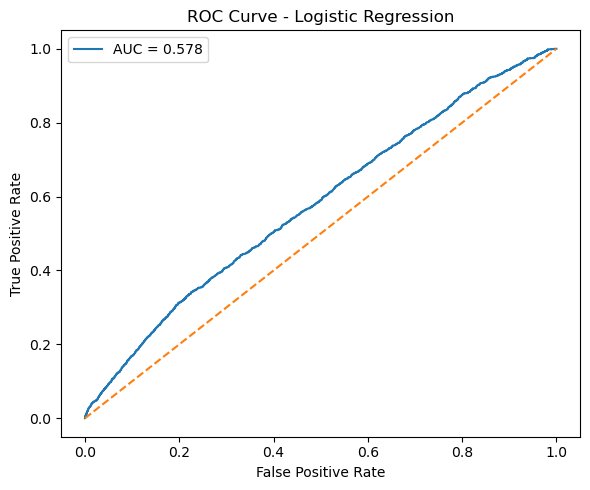

In [11]:
# ============================================================
# 13. ROC curve
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 14. Coefficients / Odds Ratios
#
# This gives interpretable results for the report:
# odds_ratio > 1  => increases odds of severe crash
# odds_ratio < 1  => decreases odds of severe crash
# ============================================================
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
coefs = clf.named_steps["model"].coef_[0]

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("odds_ratio", ascending=False)

print("\nTop positive associations with severe crashes:")
display(coef_table.head(15))

print("\nTop negative associations with severe crashes:")
display(coef_table.tail(15).sort_values("odds_ratio", ascending=True))


Top positive associations with severe crashes:


,feature,coefficient,odds_ratio
20,cat__traffic_control_device_NO PASSING,1.461688,4.313234
29,cat__traffic_control_device_SCHOOL ZONE,1.067179,2.907167
18,cat__traffic_control_device_LANE USE MARKING,0.263099,1.300955
22,cat__traffic_control_device_OTHER RAILROAD CRO...,0.259554,1.296351
45,cat__intersection_related_i_Y,0.203582,1.225785
4,num__night_time,0.148026,1.159543
40,cat__roadway_surface_cond_OTHER,0.083868,1.087486
5,num__weekend,0.063233,1.065275
44,cat__roadway_surface_cond_WET,0.051232,1.052567
7,num__rain_rushhour,0.030176,1.030636



Top negative associations with severe crashes:


,feature,coefficient,odds_ratio
16,cat__traffic_control_device_DELINEATORS,-1.622597,0.197386
28,cat__traffic_control_device_RR CROSSING SIGN,-1.439735,0.236991
12,cat__weather_group_LOW_VIS,-1.142295,0.319086
43,cat__roadway_surface_cond_UNKNOWN,-0.632286,0.531376
30,cat__traffic_control_device_STOP SIGN/FLASHER,-0.524730,0.591715
38,cat__lighting_condition_UNKNOWN,-0.510809,0.600010
31,cat__traffic_control_device_TRAFFIC SIGNAL,-0.441801,0.642877
42,cat__roadway_surface_cond_SNOW OR SLUSH,-0.436211,0.646481
32,cat__traffic_control_device_UNKNOWN,-0.431545,0.649505
19,cat__traffic_control_device_NO CONTROLS,-0.423113,0.655005


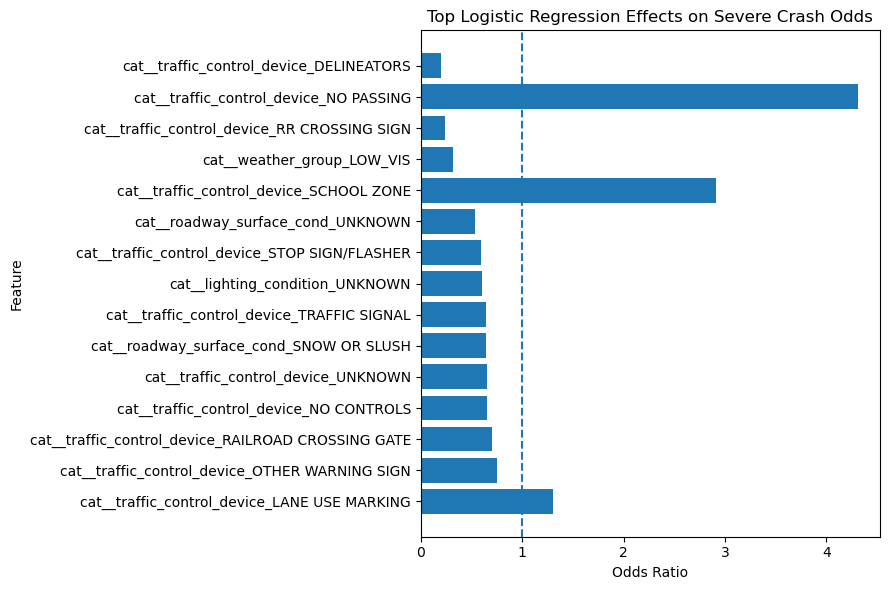

In [13]:

# ============================================================
# 15. Plot top odds ratios
#    (Most useful for the report / blog post)
# ============================================================
plot_df = coef_table.copy()

# Keep only stronger effects to avoid a huge unreadable chart
plot_df["abs_log_or"] = np.abs(np.log(plot_df["odds_ratio"]))
plot_df = plot_df.sort_values("abs_log_or", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"][::-1], plot_df["odds_ratio"][::-1])
plt.axvline(1.0, linestyle="--")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Effects on Severe Crash Odds")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 16. Simple grouped analysis for interaction interpretation
#    These tables help you explain interaction findings in words.
# ============================================================
interaction_summary = (
    df_model.groupby(["weather_group", "rush_hour"])["severe"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "severe_rate", "count": "n"})
    .sort_values(["weather_group", "rush_hour"])
)

print("\nSevere rate by weather group and rush hour:")
display(interaction_summary)

crosswalk_summary = (
    df_model.groupby(["pedestrian_crossing", "rush_hour"])["severe"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "severe_rate", "count": "n"})
    .sort_values(["pedestrian_crossing", "rush_hour"])
)

print("\nSevere rate by pedestrian crossing and rush hour:")
display(crosswalk_summary)


# ============================================================
# 17. Optional: save outputs for your team
# ============================================================
coef_table.to_csv("logistic_regression_odds_ratios.csv", index=False)
interaction_summary.to_csv("interaction_summary_weather_rushhour.csv", index=False)
crosswalk_summary.to_csv("interaction_summary_crosswalk_rushhour.csv", index=False)

print("\nSaved:")
print("- logistic_regression_odds_ratios.csv")
print("- interaction_summary_weather_rushhour.csv")
print("- interaction_summary_crosswalk_rushhour.csv")


Severe rate by weather group and rush hour:


,weather_group,rush_hour,severe_rate,n
0,CLEAR,0,0.037327,105473
1,CLEAR,1,0.029476,59200
2,CLOUDY,0,0.034601,4364
3,CLOUDY,1,0.023359,3168
4,LOW_VIS,0,0.025105,239
5,LOW_VIS,1,0.000000,121
6,OTHER,0,0.019941,4714
7,OTHER,1,0.011290,2480
8,RAIN,0,0.033943,14318
9,RAIN,1,0.030149,7894



Severe rate by pedestrian crossing and rush hour:


,pedestrian_crossing,rush_hour,severe_rate,n
0,0,0,0.035616,133507
1,0,1,0.028191,75521
2,1,0,0.112676,142
3,1,1,0.133333,105



Saved:
- logistic_regression_odds_ratios.csv
- interaction_summary_weather_rushhour.csv
- interaction_summary_crosswalk_rushhour.csv
